In [1]:
import mne 
import pandas as pd
import numpy as np
import pathlib


In [2]:
raw = mne.io.read_raw_bdf(r"C:\Users\Marcio Neves\Documents\Doutorado\dados\RAW BDF FILES (ARQUIVOS BDF BRUTOS)\RAW (BRUTOS)\ANDREIA GISELE\ANDREIA GISELE_20241101\Aquisição de Dados_Andreia_Gisele_HSM\TestdataANDREIA_GISELE_20241101_piscada.bdf")

Extracting BDF parameters from C:\Users\Marcio Neves\Documents\Doutorado\dados\RAW BDF FILES (ARQUIVOS BDF BRUTOS)\RAW (BRUTOS)\ANDREIA GISELE\ANDREIA GISELE_20241101\Aquisição de Dados_Andreia_Gisele_HSM\TestdataANDREIA_GISELE_20241101_piscada.bdf...
Setting channel info structure...
Creating raw.info structure...


In [3]:
print(raw)

<RawBDF | TestdataANDREIA_GISELE_20241101_piscada.bdf, 73 x 29696 (29.0 s), ~73 KiB, data not loaded>


In [4]:
print(raw.info['sfreq'])

1024.0


In [5]:
print(raw.ch_names)

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P8', 'P6', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']


In [6]:
data = raw.get_data()

In [7]:
data

array([[-1.59673611e-02, -1.59522049e-02, -1.59234862e-02, ...,
        -1.60382360e-02, -1.60025798e-02, -1.60146735e-02],
       [-1.60605797e-02, -1.60481735e-02, -1.60399547e-02, ...,
        -1.60522047e-02, -1.60413922e-02, -1.60280798e-02],
       [-1.69347343e-02, -1.69040469e-02, -1.68433595e-02, ...,
        -1.68192033e-02, -1.67527972e-02, -1.67844221e-02],
       ...,
       [-2.00000115e-01, -2.00000115e-01, -2.00000115e-01, ...,
        -2.00000115e-01, -2.00000115e-01, -2.00000115e-01],
       [-2.00000115e-01, -2.00000115e-01, -2.00000115e-01, ...,
        -2.00000115e-01, -2.00000115e-01, -2.00000115e-01],
       [ 6.55360000e+04,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [8]:
times = raw.times

In [9]:
times

array([0.00000000e+00, 9.76562500e-04, 1.95312500e-03, ...,
       2.89970703e+01, 2.89980469e+01, 2.89990234e+01])

In [32]:
raw_eeg = raw.copy().pick_types(eeg=True, eog=False, stim=False, exclude="bads")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [33]:
raw_eeg

<RawBDF | TestdataANDREIA_GISELE_20241101_piscada.bdf, 72 x 29696 (29.0 s), ~72 KiB, data not loaded>

In [36]:
raw_eeg.load_data()
raw_eeg = raw_eeg.set_eeg_reference("average")
raw_eeg = raw_eeg.filter(l_freq=1.0, h_freq=40.0)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (3.302 s)



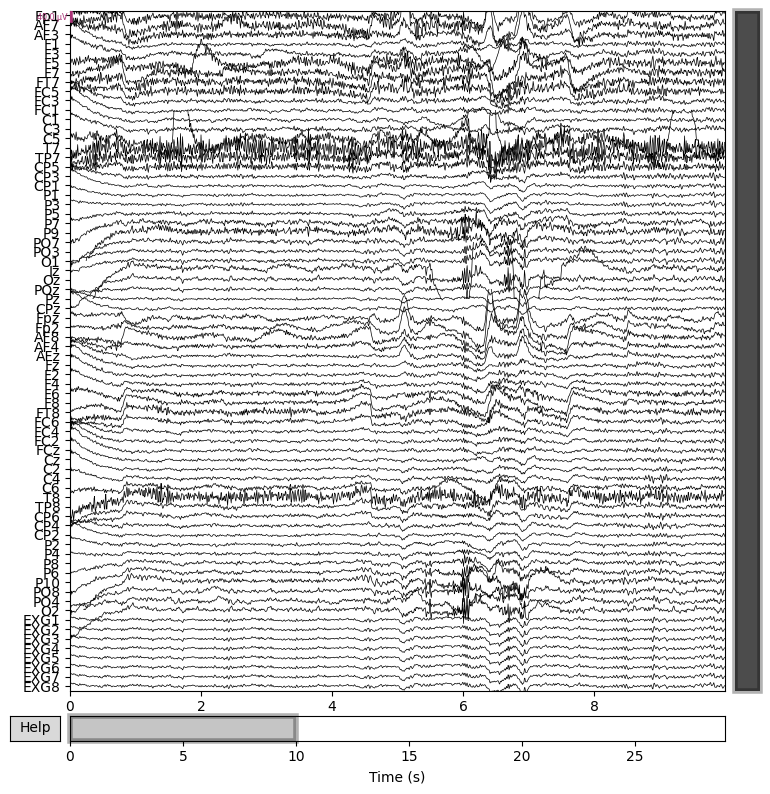

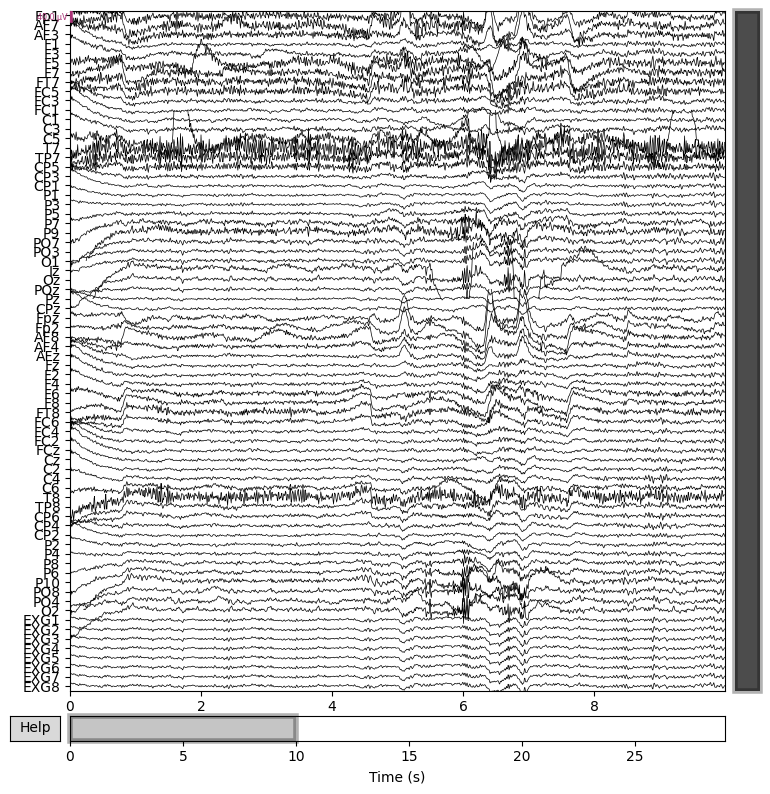

In [37]:
raw_eeg.plot(
    duration=10,   # segundos visíveis por vez
    n_channels=72  # quantos canais mostrar
)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_11392\2055971021.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.plot_psd(fmin=1, fmax=40)
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


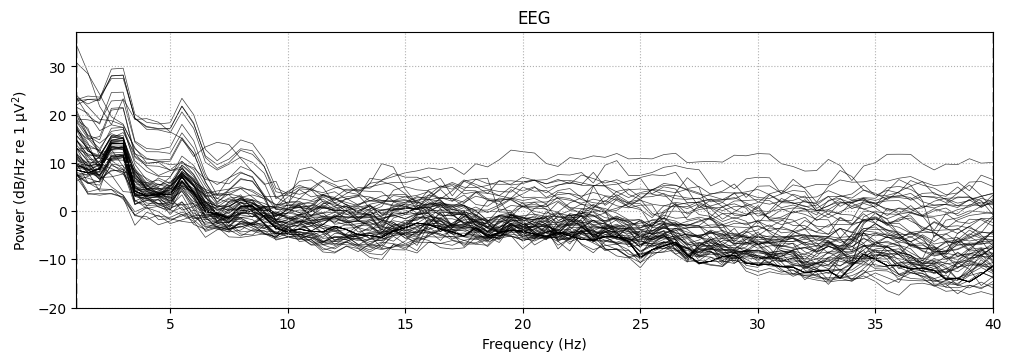

In [38]:
raw_eeg.plot_psd(fmin=1, fmax=40)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 2.000 (s)


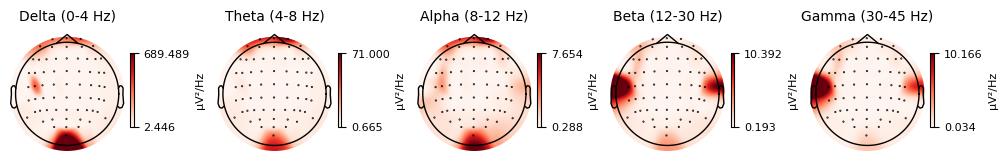

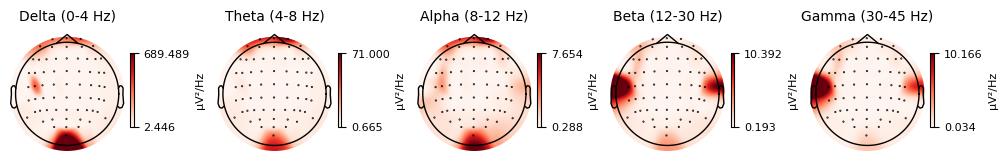

In [40]:
raw_topo = raw_eeg.copy().pick_types(eeg=True)
raw_topo.drop_channels([f"EXG{i}" for i in range(1, 9) if f"EXG{i}" in raw_topo.ch_names])
raw_topo.plot_psd_topomap(fmin=1, fmax=40)

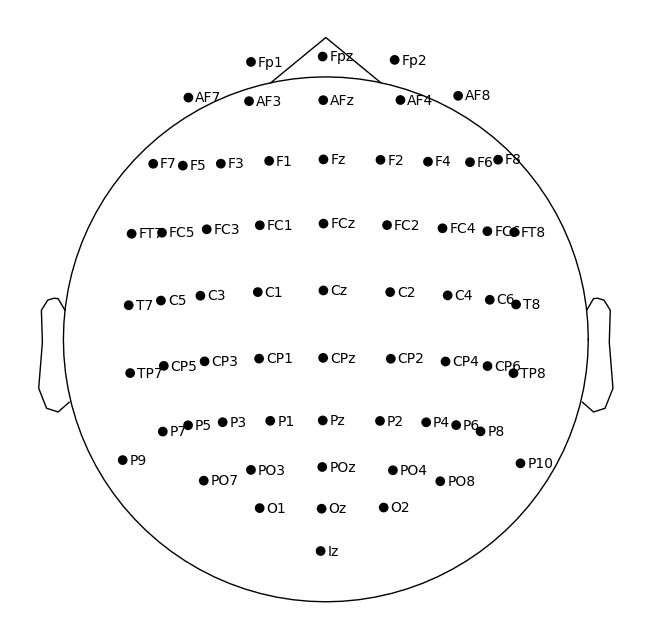

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 2.000 (s)


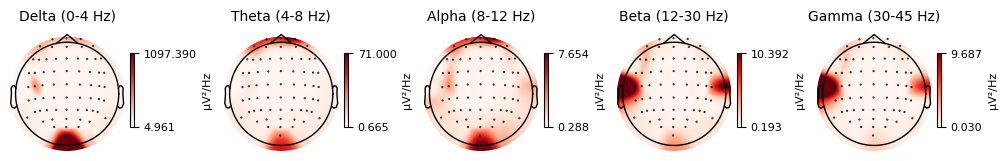

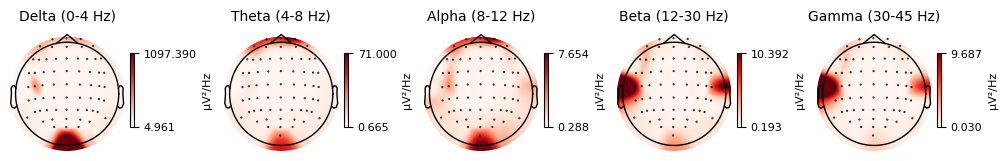

In [41]:
montage = mne.channels.make_standard_montage("standard_1020")
raw_topo.set_montage(montage, on_missing="ignore")

raw_topo.plot_sensors(show_names=True)
raw_topo.plot_psd_topomap()